In [1]:
import os
import sys; sys.path.append(os.path.abspath('..'))
from src.environment import WarehouseEnv
from src.utils.visualization import EnvironmentVisualizer, FunctionVisualizer, create_evaluation_animation
import yaml

with open("../config/warehouse_clf-cbf-rrt.yaml", 'r') as f:
    config = yaml.safe_load(f)
env = WarehouseEnv(config)



The original paper focused on linear systems and simple obstacles to guarantee tractable CLF-CBF compatibility checks. Applying it to the nonlinear unicycle model and mixed obstacles requires a few key modifications. 

1. Linearization: Linearizing the dynamics around current state x 
2. Higher order CBF. 

CBF-CLF-RRT Planning Loop
The RRT search tree $T$ is built in the 4D state space, but the core distinction is the Compatibility Check performed on every candidate edge.

Algorithm Steps
1. Initialize Tree $T$ with the start state $\mathbf{x}_{\text{init}}$.
2. Sample State: $\mathbf{x}_{\text{rand}} \leftarrow \text{RandomSample}()$.
3. Find Nearest Neighbor: $\mathbf{x}_{\text{near}} \leftarrow \text{NearestNeighbor}(T, \mathbf{x}_{\text{rand}})$.
4. Steer: $\mathbf{x}_{\text{new}} \leftarrow \text{Steer}(\mathbf{x}_{\text{near}}, \mathbf{x}_{\text{rand}}, \eta)$, generating a short, connecting segment.
5. Collision Check: If the segment is not $\text{collision-free}$ in $(x, y)$, discard the edge.
6. Compatibility Check (CRITICAL STEP): For the segment $\overline{\mathbf{x}_{\text{near}}\mathbf{x}_{\text{new}}}$, solve the Quadratic Program (QP).
7. Goal: Check if a control input $\mathbf{u}$ exists at every point on the segment that satisfies the combined CLF-CBF constraints.
8. If Feasible: Add $\mathbf{x}_{\text{new}}$ to $T$ and add the edge $\mathbf{x}_{\text{near}} \to \mathbf{x}_{\text{new}}$.
9. If Infeasible: Discard the edge.
10. Goal Check: If $\mathbf{x}_{\text{new}}$ is within the goal region, return the path by tracing back parents.

Core Feasibility Check: Quadratic Program (QP)

The compatibility check (Step 6) is implemented by checking the feasibility of a single-step control input $\mathbf{u}$ that satisfies three types of constraints simultaneously.

Optimization Problem (Solved at each step $\mathbf{x}_k$ along the segment)

$$\begin{aligned} \min_{\mathbf{u} \in \mathbb{R}^2} \quad & \| \mathbf{u} \|^2 \quad (\text{Minimize control effort}) \\ \text{s.t.} \quad & \mathbf{u}_{\text{min}} \le \mathbf{u} \le \mathbf{u}_{\text{max}} \quad (\text{Input Constraints}) \\ & L_g V(\mathbf{x}_k) \mathbf{u} \le -L_f V(\mathbf{x}_k) - \alpha_{\text{CLF}} V(\mathbf{x}_k) \quad (\text{CLF Constraint}) \\ & L_g L_f h_i(\mathbf{x}_k) \mathbf{u} \ge -L_f^2 h_i(\mathbf{x}_k) - \kappa(\dot{h}_i, h_i) \quad (\text{CBF Constraints}) \end{aligned}$$


CLF (Goal) - Ensures progress towards the target waypoint $\mathbf{x}_{\text{new}}$.

$\dot{V}(\mathbf{x}) \le -\alpha_{\text{CLF}} V(\mathbf{x})$

$L_f V(\mathbf{x})$, $L_g V(\mathbf{x})$

CBF (Safety) - Ensures the predicted acceleration $\ddot{h}$ keeps the robot safe from obstacle $i$.

$\ddot{h}_i(\mathbf{x}, \mathbf{u}) \ge -\kappa(\dot{h}_i, h_i)$

$L_f^2 h_i(\mathbf{x})$, $L_g L_f h_i(\mathbf{x})$

Input: Bounds the physical limits of the unicycle.

Feasibility Check: If the QP solver returns a solution (optimal or near-optimal status), the segment is compatible. If the QP solver returns infeasible (no $\mathbf{u}$ exists that satisfies all constraints), the segment is incompatible and is pruned.



In [2]:
from src.baselines import CCLFCBFRRT
import numpy as np

# The implementation is now in src/baselines/clf_cbf_rrt_planner.py
# It includes:
# - UnicyclePlannerCore: Handles Lie derivative calculations and QP solving
# - CCLFCBFRRT: Main RRT planner that uses CLF-CBF compatibility checking

(<Figure size 1400x1200 with 1 Axes>,
 <Axes: xlabel='X Position (meters)', ylabel='Y Position (meters)'>)

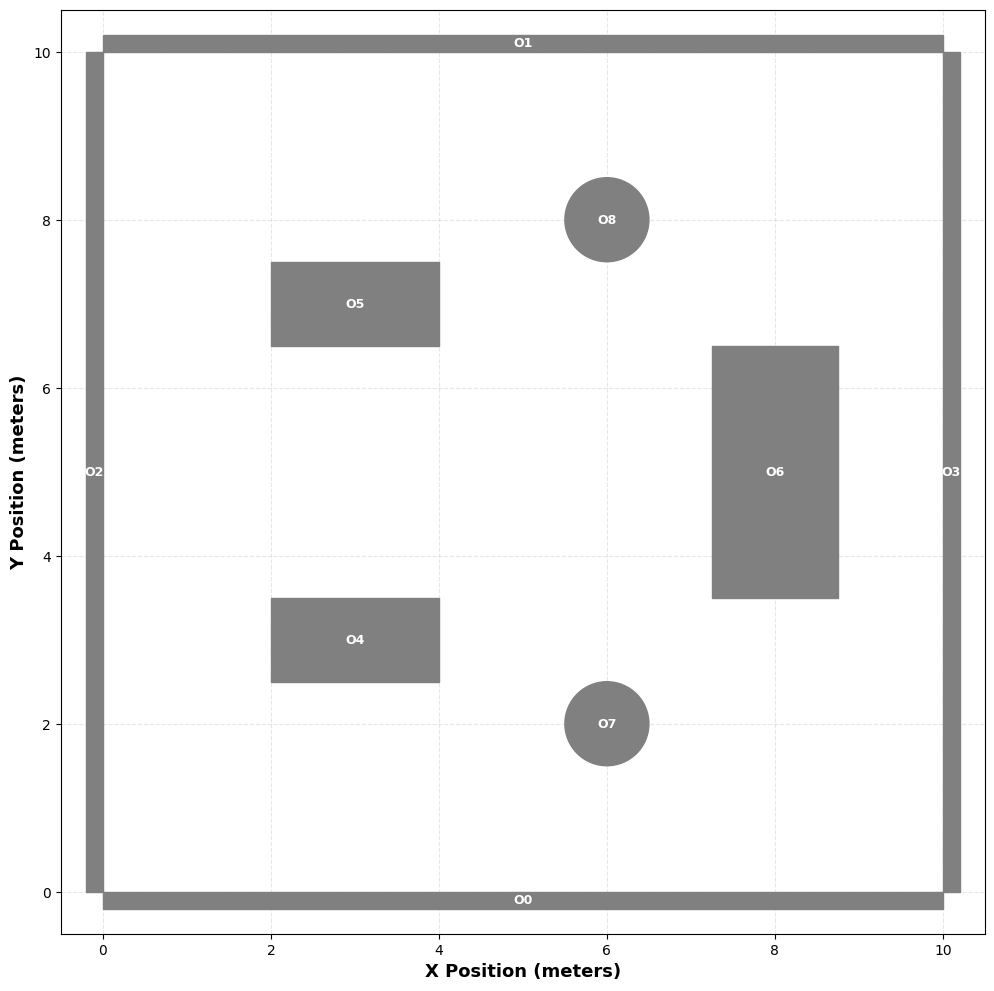

In [3]:
env = WarehouseEnv(config)
EnvironmentVisualizer(env).plot_environment()

This uses:
- Adaptive CLF constraint: Scales with distance to goal (less strict when far)
- Conditional CLF enforcement: Only enforces CLF when within 5m of goal; during exploration, only CBF constraints are checked
- Slack variables: Added to both CLF and CBF constraints to improve QP feasibility
- Debugging output: Added to show which checks pass/fail

Initial bug: When the robot is stopped (v=0) and far from the goal, the CLF constraint requires immediate progress, which can be infeasible. The constraint LgV * u <= -LfV - alpha_clf * V becomes very strict when V is large (far from goal) and v=0 (LfV=0).

The fix:
- During exploration (far from goal): Skip CLF constraint, only check CBF (safety)
- Near goal (<5m): Enforce CLF with adaptive alpha
- Always: Use slack variables to handle edge cases
This allows the tree to expand. The planner will focus on safety (CBF) during exploration and add goal-reaching (CLF) when close to the goal.

Searching for the Lyapunov function is not guaranteed and it is very time consuming. Not so natural to find Lyapunov functions, since there are properties you have to satisfy. Here all the obstacles and destinations are a convex shape. 

Planning from [1. 1.] to [10. 10.]
Running C-CLF-CBF-RRT planner...
Sampled random state: [1.8671238  5.02251396 5.15219726 0.        ]
Nearest neighbor: [1. 1. 0. 0.]
Steered: [1.12305408 1.57083745 0.7311515  0.        ]
  ✓ Collision check passed
Polishing not needed - no active set detected at optimal point
  ✓ CLF-CBF compatibility check passed
Sampled random state: [0.94287642 0.74384728 5.47766527 0.        ]
Nearest neighbor: [1. 1. 0. 0.]
Steered: [0.94287642 0.74384728 5.47766527 0.        ]
  ✓ Collision check passed
Polishing not needed - no active set detected at optimal point
  ✓ CLF-CBF compatibility check passed
Sampled random state: [1.96085612 6.33239569 1.16855667 0.        ]
Nearest neighbor: [1.12305408 1.57083745 0.7311515  0.        ]
Steered: [1.2260954  2.15646177 0.78494799 0.        ]
  ✓ Collision check passed
Polishing not needed - no active set detected at optimal point
  ✓ CLF-CBF compatibility check passed
Sampled random state: [0.54903631 1.39905136 1.1

/Users/matthewtaruno/Dev/long-horizon/src/utils/visualization.py:186: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  goal_circle = patches.Circle(


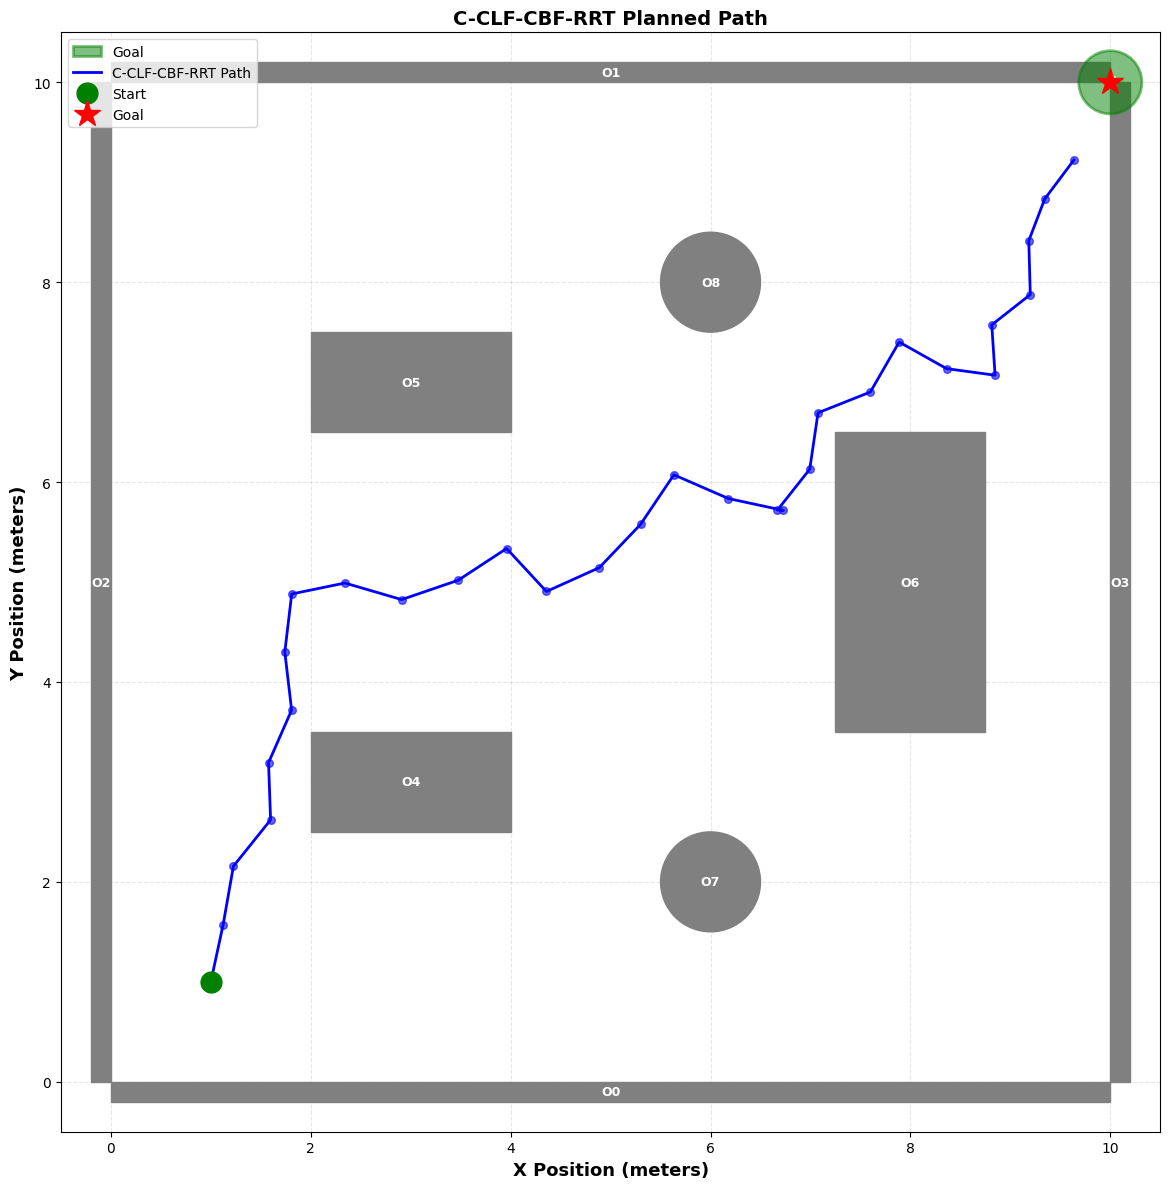

In [4]:
# Example: Plan a path using C-CLF-CBF-RRT
import matplotlib.pyplot as plt

# Initialize planner
planner = CCLFCBFRRT(
    env=env,
    config=config,
    max_iter=2000,  # Maximum RRT iterations
    step_size=0.6,   # Maximum step size for steering
    goal_tolerance=1  # Distance threshold for goal reaching
)

# Define start and goal states
# Start: [x, y, theta, v] - internal state format
x_init = np.array([1.0, 1.0, 0.0, 0.0])  # Start at (1, 1), facing right, stopped
x_goal = np.array([10.0, 10.0, 0.0, 0.0])  # Goal position (can be 2D or 4D)


print(f"Planning from {x_init[:2]} to {x_goal[:2]}")
print("Running C-CLF-CBF-RRT planner...")

# Plan path
path = planner.plan(x_init, x_goal)

if path is not None:
    print(f"\n✓ Path found! ({len(path)} waypoints)")
    print(f"  First waypoint: {path[0][:2]}")
    print(f"  Last waypoint: {path[-1][:2]}")
    
    # Visualize the path
    viz = EnvironmentVisualizer(env)
    fig, ax = viz.plot_environment(goal=x_goal)
    
    # Plot path
    path_array = np.array(path)
    ax.plot(path_array[:, 0], path_array[:, 1], 'b-', linewidth=2, label='C-CLF-CBF-RRT Path', zorder=3)
    ax.scatter(path_array[:, 0], path_array[:, 1], c='blue', s=30, zorder=4, alpha=0.6)
    
    # Plot start and goal
    ax.plot(x_init[0], x_init[1], 'go', markersize=15, label='Start', zorder=5)
    ax.plot(x_goal[0], x_goal[1], 'r*', markersize=20, label='Goal', zorder=5)
    
    ax.set_title("C-CLF-CBF-RRT Planned Path", fontsize=14, fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.show()
    
else:
    print("\n✗ Planning failed - no path found")
    print("  Try increasing max_iter or adjusting step_size/goal_tolerance")


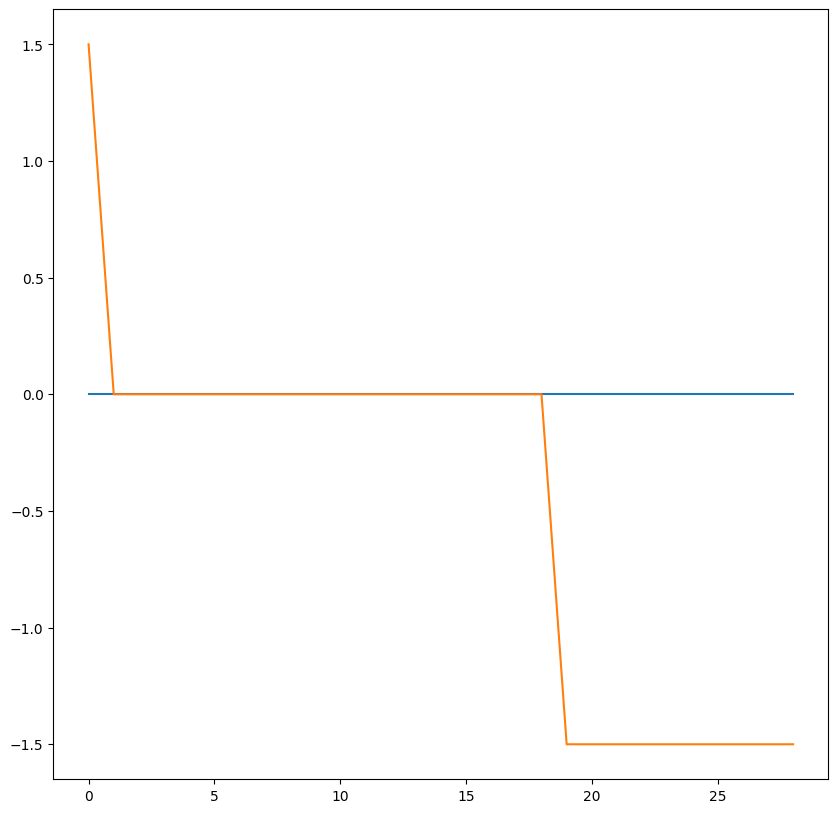

In [7]:
actions = planner.get_actions()

# visualize actions
import matplotlib.pyplot as plt

# Create a figure for the animation
fig, ax = plt.subplots(figsize=(10, 10))
plt.plot(actions)
plt.show()

In [10]:
# Create animation of the CLF-CBF-RRT rollout
import imageio

if path is not None:
    print(f"\nCreating animation of CLF-CBF-RRT rollout...")
    
    # Option 1: Animate using the planned path waypoints directly
    # Convert internal states [x, y, theta, v] to NN states [x, y, cos(theta), sin(theta), v]
    nn_path = []
    for state in path:
        x, y, theta, v = state
        nn_state = np.array([x, y, np.cos(theta), np.sin(theta), v])
        nn_path.append(nn_state)
    
    # Create animation
    goal_pos = x_goal[:2] if len(x_goal) >= 2 else x_goal
    create_evaluation_animation(
        env=env,
        path=nn_path,
        goal=goal_pos,
        filename="clf_cbf_rrt_rollout.gif"
    )
    print("✓ Animation saved as 'clf_cbf_rrt_rollout.gif'")
    
    # Option 2: Simulate actual rollout by following waypoints with QP-based control
    # This shows how the robot would actually move when following the planned path
    print("\nSimulating actual rollout by following waypoints...")
    rollout_states = []
    rollout_actions = []
    
    # Reset environment to start position
    env.reset(start_pos=x_init[:2])
    current_internal_state = x_init.copy()  # [x, y, theta, v]
    rollout_states.append(env.get_nn_state(current_internal_state))
    
    # Follow waypoints one by one
    waypoint_tolerance = 0.3  # Distance threshold to consider waypoint reached
    max_steps_per_waypoint = 200  # Max steps to reach each waypoint
    max_total_steps = 2000  # Total max steps
    
    for wp_idx in range(1, len(path)):
        target_waypoint = path[wp_idx]
        target_pos = target_waypoint[:2]
        
        print(f"  Navigating to waypoint {wp_idx+1}/{len(path)} at {target_pos}")
        
        steps_for_waypoint = 0
        while steps_for_waypoint < max_steps_per_waypoint and len(rollout_states) < max_total_steps:
            # Get current position
            current_pos = current_internal_state[:2]
            dist_to_target = np.linalg.norm(current_pos - target_pos)
            
            # Check if we've reached this waypoint
            if dist_to_target < waypoint_tolerance:
                print(f"    ✓ Reached waypoint {wp_idx+1} at step {len(rollout_states)}")
                break
            
            # Try QP solver first, but prefer fallback controller for actual execution
            # (QP is designed for feasibility checking, not optimal control)
            use_qp = False  # Set to True to try QP, False to use fallback directly
            action = None
            is_feasible = False
            
            if use_qp:
                is_feasible, action = planner.core._solve_qp_at_state(
                    current_internal_state, 
                    target_waypoint, 
                    return_action=True
                )
                
                # Check if action is too small (QP minimizes effort, so actions can be tiny)
                if action is not None:
                    action_magnitude = np.linalg.norm(action)
                    if action_magnitude < 0.1:  # Action too small, use fallback
                        is_feasible = False
                        action = None
            
            if not is_feasible or action is None:
                # Fallback: More aggressive proportional control
                theta = current_internal_state[2]
                v = current_internal_state[3]
                
                # Compute desired heading
                to_target = target_pos - current_pos
                desired_heading = np.arctan2(to_target[1], to_target[0])
                heading_error = desired_heading - theta
                # Normalize to [-pi, pi]
                while heading_error > np.pi:
                    heading_error -= 2 * np.pi
                while heading_error < -np.pi:
                    heading_error += 2 * np.pi
                
                # More aggressive control: prioritize getting moving
                # If velocity is very low, give strong acceleration
                if v < 0.1:
                    # Strong initial acceleration to get moving
                    a = min(env.a_max * 0.8, dist_to_target * 2.0)  # Scale with distance
                else:
                    # Normal speed control
                    desired_speed = min(0.8, dist_to_target * 0.5)  # Faster desired speed
                    a = np.clip((desired_speed - v) / max(env.dt, 1e-3), -env.a_max, env.a_max)
                
                # Angular control: stronger when far from target heading
                omega_gain = 3.0 if abs(heading_error) > 0.5 else 2.0  # More aggressive
                omega = np.clip(omega_gain * heading_error, -env.omega_max, env.omega_max)
                
                action = np.array([a, omega])
            
            # Ensure action has minimum magnitude if robot is stopped
            if current_internal_state[3] < 0.05:  # Very low velocity
                action_magnitude = np.linalg.norm(action)
                if action_magnitude < 0.1:  # Action too small
                    # Force minimum acceleration to get moving
                    if abs(action[0]) < 0.1:
                        action[0] = np.sign(action[0]) * max(0.1, env.a_max * 0.3)
            
            # Apply action
            nn_state_next, _, done, info = env.step(action)
            rollout_states.append(nn_state_next.copy())
            rollout_actions.append(action.copy())
            
            # Update internal state from NN state
            x, y = nn_state_next[0], nn_state_next[1]
            cos_theta, sin_theta = nn_state_next[2], nn_state_next[3]
            v = nn_state_next[4]
            theta = np.arctan2(sin_theta, cos_theta)
            current_internal_state = np.array([x, y, theta, v])
            
            if info['is_collision']:
                print(f"    ⚠️  Collision detected at step {len(rollout_states)}")
                break
            
            steps_for_waypoint += 1
        
        # Check if we reached the goal
        if wp_idx == len(path) - 1:  # Last waypoint
            final_pos = rollout_states[-1][:2]
            if np.linalg.norm(final_pos - goal_pos) < 0.5:
                print(f"  ✓ Reached goal!")
                break
        
        if len(rollout_states) >= max_total_steps:
            print(f"  ⚠️  Reached max total steps ({max_total_steps})")
            break
    
    # Create animation of simulated rollout
    if len(rollout_states) > 1:
        create_evaluation_animation(
            env=env,
            path=rollout_states,
            goal=goal_pos,
            filename="clf_cbf_rrt_simulated_rollout.gif"
        )
        print(f"✓ Simulated rollout animation saved as 'clf_cbf_rrt_simulated_rollout.gif'")
        print(f"  Total steps: {len(rollout_states)}, Total actions: {len(rollout_actions)}")
    else:
        print("  ⚠️  No rollout states generated - simulation failed")
else:
    print("No path to animate - planning failed")



Creating animation of CLF-CBF-RRT rollout...
Creating evaluation animation at clf_cbf_rrt_rollout.gif...
... animation saved.
✓ Animation saved as 'clf_cbf_rrt_rollout.gif'

Simulating actual rollout by following waypoints...
  Navigating to waypoint 2/30 at [1.12305408 1.57083745]
    ✓ Reached waypoint 2 at step 35
  Navigating to waypoint 3/30 at [1.2260954  2.15646177]
    ✓ Reached waypoint 3 at step 80
  Navigating to waypoint 4/30 at [1.59809334 2.6202489 ]
    ✓ Reached waypoint 4 at step 124
  Navigating to waypoint 5/30 at [1.57754264 3.19274478]
    ✓ Reached waypoint 5 at step 166
  Navigating to waypoint 6/30 at [1.80849326 3.71846564]
    ✓ Reached waypoint 6 at step 210
  Navigating to waypoint 7/30 at [1.74029645 4.29974927]
    ✓ Reached waypoint 7 at step 254
  Navigating to waypoint 8/30 at [1.80928295 4.88039529]
    ✓ Reached waypoint 8 at step 298
  Navigating to waypoint 9/30 at [2.34166112 4.99005649]
    ✓ Reached waypoint 9 at step 334
  Navigating to waypoin

In [11]:
# Debug: Check what actions are being computed
# Run a quick test to see if QP is giving reasonable actions
if path is not None and len(path) > 1:
    test_state = path[0].copy()  # Start state
    test_target = path[1].copy()  # First waypoint
    
    print("Testing QP solver on first waypoint segment:")
    print(f"  Start state: {test_state}")
    print(f"  Target waypoint: {test_target}")
    
    is_feasible, action = planner.core._solve_qp_at_state(
        test_state, 
        test_target, 
        return_action=True
    )
    
    print(f"  QP feasible: {is_feasible}")
    if action is not None:
        print(f"  QP action: a={action[0]:.4f}, omega={action[1]:.4f}")
        print(f"  Action magnitude: {np.linalg.norm(action):.4f}")
        print(f"  a_max={env.a_max}, omega_max={env.omega_max}")
    else:
        print("  QP returned None action")
    
    # Test fallback controller
    theta = test_state[2]
    v = test_state[3]
    to_target = test_target[:2] - test_state[:2]
    desired_heading = np.arctan2(to_target[1], to_target[0])
    heading_error = desired_heading - theta
    while heading_error > np.pi:
        heading_error -= 2 * np.pi
    while heading_error < -np.pi:
        heading_error += 2 * np.pi
    
    if v < 0.1:
        a_fallback = min(env.a_max * 0.8, np.linalg.norm(to_target) * 2.0)
    else:
        desired_speed = min(0.8, np.linalg.norm(to_target) * 0.5)
        a_fallback = np.clip((desired_speed - v) / max(env.dt, 1e-3), -env.a_max, env.a_max)
    
    omega_fallback = np.clip(3.0 * heading_error, -env.omega_max, env.omega_max)
    action_fallback = np.array([a_fallback, omega_fallback])
    
    print(f"\nFallback controller action: a={action_fallback[0]:.4f}, omega={action_fallback[1]:.4f}")
    print(f"Fallback action magnitude: {np.linalg.norm(action_fallback):.4f}")


Testing QP solver on first waypoint segment:
  Start state: [1. 1. 0. 0.]
  Target waypoint: [1.12305408 1.57083745 0.7311515  0.        ]
  QP feasible: True
  QP action: a=0.0000, omega=1.5000
  Action magnitude: 1.5000
  a_max=1.0, omega_max=1.5

Fallback controller action: a=0.8000, omega=1.5000
Fallback action magnitude: 1.7000
